#   6TO CHALLENGE THE HUDDLE LOGS

importamos las librerias necesarias, ene este caso importaremos lo que seria pandas

In [23]:
!pip install matplotlib pandas

Defaulting to user installation because normal site-packages is not writeable


In [24]:
# (This is for the Python cell; update it in VS Code)

import pandas as pd
import matplotlib.pyplot as plt

In [25]:
df = pd.read_csv("server_logs.csv")

df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5795 entries, 0 to 5794
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   timestamp_event  5795 non-null   str  
 1   received_at      5795 non-null   str  
 2   service_name     5795 non-null   str  
 3   severity         5795 non-null   str  
 4   message          5795 non-null   str  
 5   trace_id         5795 non-null   str  
 6   request_id       5795 non-null   str  
 7   method           5795 non-null   str  
 8   endpoint         5795 non-null   str  
 9   status_code      5795 non-null   int64
 10  latency_ms       5795 non-null   int64
 11  host             5795 non-null   str  
 12  env              5795 non-null   str  
 13  region           5795 non-null   str  
 14  log_type         5795 non-null   str  
dtypes: int64(2), str(13)
memory usage: 679.2 KB


In [26]:
df["timestamp_event"] = pd.to_datetime(df["timestamp_event"])
df["window_start"] = df["timestamp_event"].dt.floor("5min")

In [27]:
df["is_bad"] = (
    (df["severity"].isin(["ERROR", "CRITICAL"])) |
    (df["status_code"] >= 500)
)

In [28]:
total_logs= len(df)
print(f'total de logs: {total_logs}')

print('Severity mas comun')
df["severity"].value_counts()


total de logs: 5795
Severity mas comun


severity
INFO        3542
WARN        1358
ERROR        775
CRITICAL     120
Name: count, dtype: int64

In [29]:
df["severity"].value_counts()

severity
INFO        3542
WARN        1358
ERROR        775
CRITICAL     120
Name: count, dtype: int64

In [30]:
df["service_name"].value_counts()

service_name
api-gateway             1509
orders-service          1057
inventory-service        964
payment-service          842
auth-service             778
notification-service     645
Name: count, dtype: int64

In [31]:
df["message"].value_counts().head(1)

message
Health check OK    1196
Name: count, dtype: int64

In [32]:
df[df["is_bad"]]["message"].value_counts().head(1)

message
Order creation failed - inventory lock timeout    197
Name: count, dtype: int64

In [33]:
window_stats = df.groupby("window_start").agg(
    total_events=("trace_id", "count"),
    bad_events=("is_bad", "sum")
)

window_stats["bad_rate"] = window_stats["bad_events"] / window_stats["total_events"]

In [34]:
window_stats = window_stats[window_stats["total_events"] >= 20]

In [35]:
top_windows = window_stats.sort_values("bad_rate", ascending=False).head(5)
top_windows

,total_events,bad_events,bad_rate
window_start,,,
2026-01-10 11:10:00+00:00,189,110,0.582011
2026-01-10 11:15:00+00:00,228,129,0.565789
2026-01-10 11:20:00+00:00,111,59,0.531532
2026-01-11 14:35:00+00:00,255,117,0.458824
2026-01-11 14:30:00+00:00,156,68,0.435897


In [37]:
critical_window = top_windows.index[0]
critical_window

Timestamp('2026-01-10 11:10:00+0000', tz='UTC')

In [38]:
df_critical = df[df["window_start"] == critical_window]
bad_critical = df_critical[df_critical["is_bad"]]


In [39]:
bad_critical["service_name"].value_counts()


service_name
orders-service       72
inventory-service    37
payment-service       1
Name: count, dtype: int64

In [40]:
bad_critical["message"].value_counts().head(5)

message
Order creation failed - inventory lock timeout    72
Database deadlock detected                        37
External dependency error                          1
Name: count, dtype: int64

In [41]:
bad_critical["endpoint"].value_counts().head(5)

endpoint
/orders/cancel    26
/orders/create    25
/orders/status    21
/inv/reserve      18
/inv/stock        13
Name: count, dtype: int64

In [42]:
baseline = df[df["window_start"] != critical_window]

In [43]:
def compute_metrics(data):
    total = len(data)
    bad = data["is_bad"].sum()
    return pd.Series(
        {
        "total_events": total,
        "bad_rate": bad / total,
        "avg_latency_ms": data["latency_ms"].mean(),
        "%_5xx": (data["status_code"] >= 500).mean()
        }
    )

In [44]:
comparison = pd.DataFrame({
    "critical": compute_metrics(df_critical),
    "baseline": compute_metrics(baseline)
})

comparison

,critical,baseline
total_events,189.000000,5606.000000
bad_rate,0.582011,0.140029
avg_latency_ms,1589.687831,521.094363
%_5xx,0.582011,0.140029


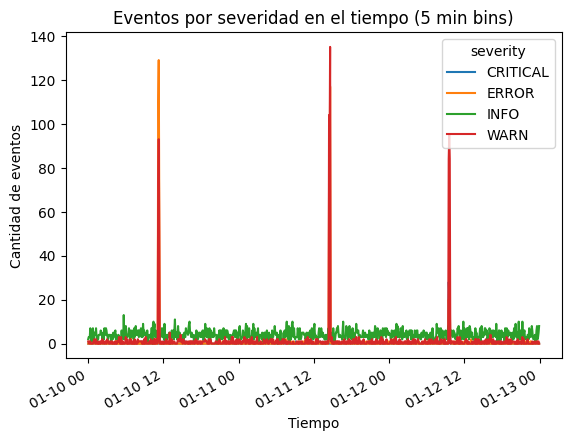

In [45]:
severity_time = df.groupby(["window_start", "severity"]).size().unstack(fill_value=0)
severity_time.plot()

plt.title("Eventos por severidad en el tiempo (5 min bins)")
plt.xlabel("Tiempo")
plt.ylabel("Cantidad de eventos")
plt.show()

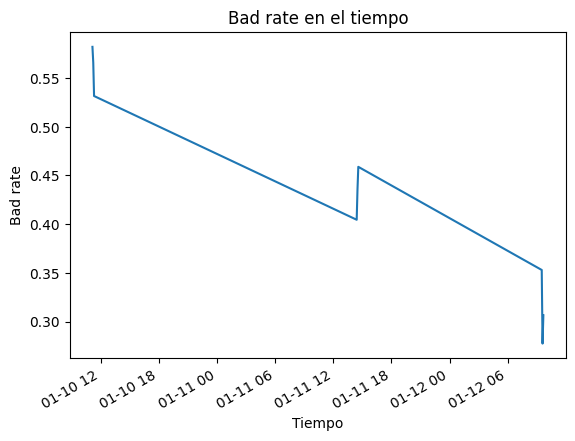

In [46]:
window_stats["bad_rate"].plot()

plt.title("Bad rate en el tiempo")
plt.xlabel("Tiempo")
plt.ylabel("Bad rate")
plt.show()